In [1]:
import os
import re
import numpy as np
import torch
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.model import SkipGramModel
from src.dataset import load_processed_data
from src.config import *
from src.utils import split_data, subsampling

In [2]:
%matplotlib inline

In [3]:
def load_model_for_notebook(epoch=None):
    bundle = load_processed_data()
    if not bundle:
        raise FileNotFoundError("error: could not find pre-processed data")
    
    word2idx = bundle['word2idx']
    vocab_size = bundle['vocab_size']
    idx2word = {i: w for w, i in word2idx.items()}
    unigram_table = bundle['unigram_table']

    files = [f for f in os.listdir(CHECKPOINT_DIR) if f.endswith('.pt')]
    if not files:
        raise FileNotFoundError("error: could not find checkpoint")

    if epoch is not None:
        target_file = f"model_e{epoch}.pt"
    else:
        target_file = max(files, key=lambda x: int(re.search(r'e(\d+)', x).group(1)))
    checkpoint_path = os.path.join(CHECKPOINT_DIR, target_file)

    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    key = "u_embeddings.weight" if "u_embeddings.weight" in checkpoint['state_dict'] else "_orig_mod.u_embeddings.weight"
    v_size, e_dim = checkpoint['state_dict'][key].shape
    
    model = SkipGramModel(
        vocab_size=v_size,
        emb_dim=e_dim,
        unigram_table=unigram_table,
        k_neg=K_NEG
    )
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()

    print("model loaded")
    return model, word2idx, idx2word
epoch=10
model, word2idx, idx2word = load_model_for_notebook(epoch)

model loaded


In [4]:
def vector(word):
    if word not in word2idx:
        return None
    return wv[word2idx[word]]

def find_closest_word(target_vector, top_k=5, exclude_words=[]):
    similarities = np.dot(wv, target_vector)
    sorted_indices = np.argsort(similarities)[::-1]
    
    results = []
    for idx in sorted_indices:
        word = idx2word[idx]
        if word not in exclude_words:
            results.append((word, similarities[idx]))
        if len(results) >= top_k:
            break
    return results

In [5]:
word_vectors = model.u_embeddings.weight.data.cpu()
norms = word_vectors.norm(p=2, dim=1, keepdim=True)
word_vectors = word_vectors / norms
wv = word_vectors.numpy()

## Aile ve Cinsiyet İlişkileri

In [6]:
v = vector
find_closest_word(v("king") - v("man") + v("woman")) # BULAMADI (queen)

[('king', np.float32(1.0189674)),
 ('son', np.float32(0.7605182)),
 ('marries', np.float32(0.74225104)),
 ('daughter', np.float32(0.7312854)),
 ('throne', np.float32(0.7188976))]

In [7]:
find_closest_word(v("prince") - v("boy") + v("girl"), 2)

[('prince', np.float32(1.1155902)), ('princess', np.float32(0.858562))]

In [8]:
find_closest_word(v("uncle") - v("man") + v("woman"), 7)

[('uncle', np.float32(1.0886089)),
 ('wife', np.float32(0.9052183)),
 ('daughter', np.float32(0.8976358)),
 ('cousin', np.float32(0.89761484)),
 ('grandmother', np.float32(0.8940176)),
 ('grandfather', np.float32(0.8927498)),
 ('aunt', np.float32(0.86159325))]

In [9]:
find_closest_word(v("son") - v("boy") + v("girl"), 3)

[('son', np.float32(1.0726688)),
 ('wife', np.float32(0.9336238)),
 ('daughter', np.float32(0.91879606))]

In [10]:
find_closest_word(v("brother") - v("man") + v("woman"), 12)

[('brother', np.float32(1.1487225)),
 ('son', np.float32(1.0024186)),
 ('wife', np.float32(0.9741845)),
 ('daughter', np.float32(0.9663155)),
 ('marry', np.float32(0.89475673)),
 ('mother', np.float32(0.8888359)),
 ('daughters', np.float32(0.8795427)),
 ('cousin', np.float32(0.8655048)),
 ('married', np.float32(0.86244905)),
 ('husband', np.float32(0.8620391)),
 ('grandmother', np.float32(0.8438791)),
 ('sister', np.float32(0.83784866))]

## Coğrafya ve Başkentler

In [11]:
find_closest_word(v("rome") - v("italy") + v("germany"), 5)

[('germany', np.float32(0.67695975)),
 ('magdeburg', np.float32(0.6293944)),
 ('augsburg', np.float32(0.6158609)),
 ('rhineland', np.float32(0.615803)),
 ('berlin', np.float32(0.59588856))]

In [12]:
find_closest_word(v("tokyo") - v("japan") + v("turkey"), 2)

[('turkey', np.float32(0.84746146)), ('ankara', np.float32(0.69972503))]

In [13]:
find_closest_word(v("paris") - v("france") + v("japan"), 2)

[('japan', np.float32(0.7095032)), ('tokyo', np.float32(0.61627024))]

In [14]:
find_closest_word(v("moscow") - v("russia") + v("spain"), 1)

[('madrid', np.float32(0.7588602))]

## Dilbilgisi ve Zamanlar

In [15]:
find_closest_word(v("swimming") - v("swim") + v("walk"), 8)

[('walk', np.float32(0.944795)),
 ('swimming', np.float32(0.71466166)),
 ('kayak', np.float32(0.57892376)),
 ('skaters', np.float32(0.57160825)),
 ('boat', np.float32(0.55604565)),
 ('halls', np.float32(0.54583275)),
 ('skating', np.float32(0.53932905)),
 ('walking', np.float32(0.5382165))]

In [16]:
find_closest_word(v("ate") - v("eat") + v("drink"), 3)

[('drink', np.float32(0.94364905)),
 ('ate', np.float32(0.8226836)),
 ('drank', np.float32(0.79925674))]

In [17]:
find_closest_word(v("took") - v("take") + v("go")) # BULAMADI (gone)

[('took', np.float32(0.9907691)),
 ('go', np.float32(0.82217777)),
 ('went', np.float32(0.72199416)),
 ('grandson', np.float32(0.69265044)),
 ('returned', np.float32(0.677497))]

## Sıfatlar ve Derecelendirme

In [18]:
find_closest_word(v("bigger") - v("big") + v("small"), 3)

[('small', np.float32(1.2299366)),
 ('bigger', np.float32(1.0108991)),
 ('smaller', np.float32(0.94712913))]

In [19]:
find_closest_word(v("fastest") - v("fast") + v("slow")) # BULAMADI (slowest)

[('fastest', np.float32(0.87780064)),
 ('slow', np.float32(0.84547603)),
 ('growth', np.float32(0.72276616)),
 ('rapid', np.float32(0.68600667)),
 ('slowdown', np.float32(0.67662))]

In [20]:
find_closest_word(v("quick") - v("quickly") + v("slow")) # BULAMADI (slowly)

[('quick', np.float32(1.0484397)),
 ('slow', np.float32(0.97725904)),
 ('slower', np.float32(0.6822276)),
 ('rapid', np.float32(0.6615503)),
 ('pace', np.float32(0.66150385))]

## Kavramsal İlişkiler

In [21]:
find_closest_word(v("doctor") - v("hospital") + v("school"), 6)

[('doctor', np.float32(0.8309629)),
 ('school', np.float32(0.78213024)),
 ('professor', np.float32(0.65294445)),
 ('satirizes', np.float32(0.6206082)),
 ('curriculum', np.float32(0.61739343)),
 ('teacher', np.float32(0.6123685))]

In [22]:
find_closest_word(v("sushi") - v("japan") + v("italy"), 15) # BULAMADI, (pizza beklerdik ama başka kayda değer şeyler var)

[('sushi', np.float32(0.9930353)),
 ('polenta', np.float32(0.9042842)),
 ('prosciutto', np.float32(0.88737047)),
 ('parmesan', np.float32(0.8539382)),
 ('ricotta', np.float32(0.84855604)),
 ('pancakes', np.float32(0.8402043)),
 ('ravioli', np.float32(0.83770025)),
 ('minestrone', np.float32(0.8330899)),
 ('savory', np.float32(0.8274876)),
 ('sausage', np.float32(0.8210011)),
 ('stewed', np.float32(0.820817)),
 ('caff', np.float32(0.81778777)),
 ('filo', np.float32(0.8038136)),
 ('salami', np.float32(0.79640675)),
 ('hearty', np.float32(0.7952001))]

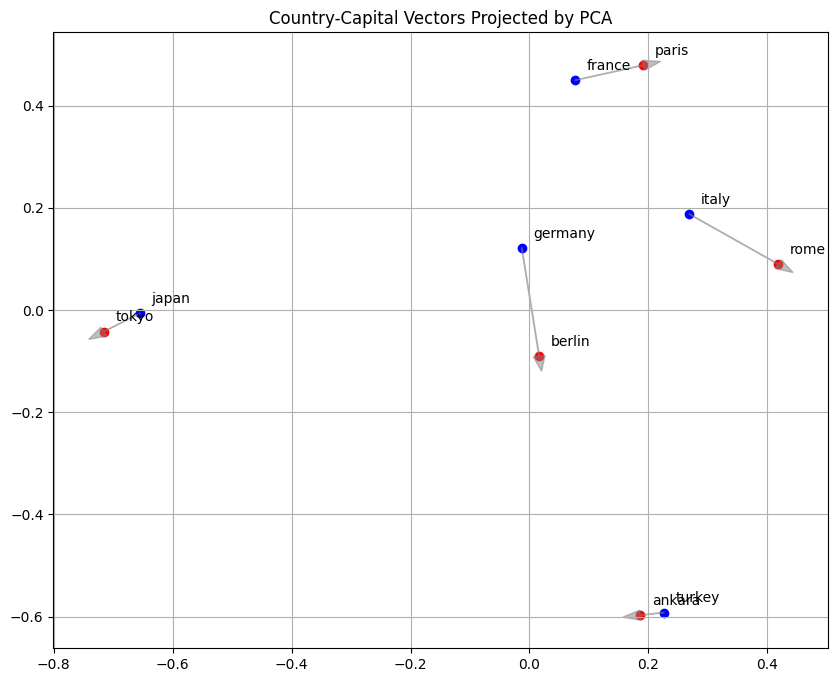

In [23]:
def plot_capitals():
    pairs = [
        ("turkey", "ankara"),
        ("france", "paris"),
        ("germany", "berlin"),
        ("japan", "tokyo"),
        ("italy", "rome")
    ]
    
    selected_words = []
    vectors_to_visualize = []
    
    for country, capital in pairs:
        v_country = vector(country)
        v_capital = vector(capital)
        
        if v_country is not None and v_capital is not None:
            selected_words.extend([country, capital])
            vectors_to_visualize.extend([v_country, v_capital])
    
    vectors_to_visualize = np.array(vectors_to_visualize)
    pca = PCA(n_components=2)
    reduced_vectors = pca.fit_transform(vectors_to_visualize)
    plt.figure(figsize=(10, 8))
    
    for i in range(0, len(reduced_vectors), 2):
        country_vec = reduced_vectors[i]
        capital_vec = reduced_vectors[i+1]
        
        # Noktaları çiz
        plt.scatter(country_vec[0], country_vec[1], color='blue')
        plt.scatter(capital_vec[0], capital_vec[1], color='red')
        
        # Kelimeleri yaz
        plt.text(country_vec[0] + 0.02, country_vec[1] + 0.02, selected_words[i])
        plt.text(capital_vec[0] + 0.02, capital_vec[1] + 0.02, selected_words[i+1])
        
        # Aradaki ilişkiyi okla göster
        plt.arrow(country_vec[0], country_vec[1], 
                  capital_vec[0] - country_vec[0], 
                  capital_vec[1] - country_vec[1], 
                  color='gray', alpha=0.5, head_width=0.02)
    
    plt.title("Country-Capital Vectors Projected by PCA")
    plt.grid(True)
    plt.show()
plot_capitals()

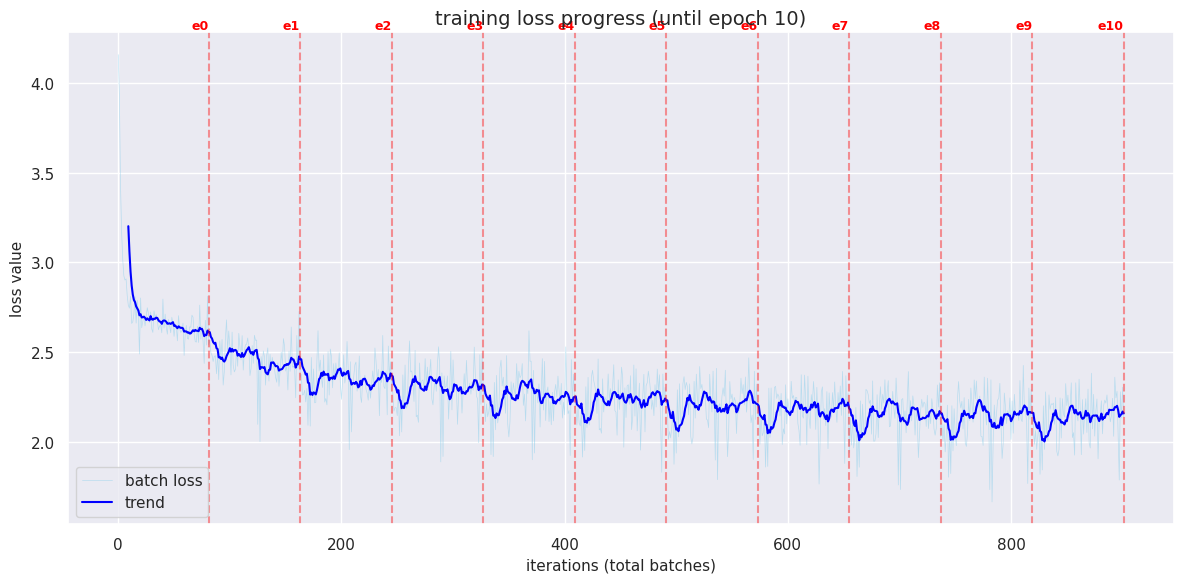

In [24]:
def plot_loss_progress(target_epoch=None):
    """
    target_epoch: İzlemek istediğin son epoch. None ise hepsini gösterir.
    """
    csv_path = os.path.join(CHECKPOINT_DIR, "train_log.csv")
    if not os.path.exists(csv_path):
        print(f"[!] {csv_path} bulunamadı!")
        return
    
    # Veriyi oku
    df = pd.read_csv(csv_path)
    
    # Filtreleme
    if target_epoch is not None:
        df = df[df['epoch'] <= target_epoch]
    else:
        target_epoch = df['epoch'].max()

    # Stil ve Figür
    sns.set_theme(style="darkgrid")
    plt.figure(figsize=(12, 6), dpi=100)
    
    # 1. Ham Loss (Şeffaf mavi)
    plt.plot(df.index, df['loss'], color='skyblue', alpha=0.5, label='batch loss', lw=0.5)
    
    # 2. Hareketli Ortalama (Trendi görmek için daha koyu mavi)
    window = max(10, len(df) // 100)
    plt.plot(df.index, df['loss'].rolling(window=window).mean(), color='blue', lw=1.5, label='trend')

    # 3. Epoch Ayraçları (Dikey kırmızı çizgiler)
    # Her epoch'un bittiği son batch'in indeksini buluyoruz
    epoch_ends = df.groupby('epoch').tail(1).index
    for e_idx in epoch_ends:
        plt.axvline(x=e_idx, color='red', linestyle='--', alpha=0.4)
        
        # Çizginin üzerine hangi epoch olduğunu yaz
        e_val = df.loc[e_idx, 'epoch']
        plt.text(e_idx, plt.gca().get_ylim()[1], f"e{int(e_val)}", 
                 color='red', fontsize=9, ha='right', va='bottom', fontweight='bold')

    plt.title(f"training loss progress (until epoch {target_epoch})", fontsize=14)
    plt.xlabel("iterations (total batches)", fontsize=11)
    plt.ylabel("loss value", fontsize=11)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
plot_loss_progress(epoch)